In [2]:
%pip install scikit-learn joblib

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 16.3 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/8.3 MB 9.9 MB/s eta 0:00:01
   ----- ---------------------------------- 1.0/8.3 MB 8.3 MB/s eta 0:00:01
   ------ --------------------------------- 1.4/8.3 MB 7.8 MB/s eta 0:00:01
   ------- -------------------------------- 1.6/8.3 MB 7.0 MB/s eta 0:00:01
   --------- ------------------------------ 2.0/8.3 MB 7.0 MB/s eta 0:00:01
   ---------- ----------------------------- 2.3/8.3 MB 6.9 MB/s eta 0:00:01
   ------------ --------------------------- 2.5/8.3 MB 7.0 MB/s eta 0:00:01
   ------------- -------------------------- 2.8/8.3 MB 6.8 MB/s eta 0:00:01
   -------------- ------------------------- 3.0/8.3 MB 6.6 MB/s eta 0:00:01
   ---------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [4]:
df = pd.read_csv(
    "../datasets/inventory/Inventory_Transactions.csv"
)

In [ ]:
df.head()

,Order_ID,Date,SKU,Qty_Sold,Location,Staff_ID,Revenue,Lead_Time,Risk_Level
0,ORD-501,9/22/2025,SURG-P-02,18,North,Optician_A,1530.0,30,Medium Risk
1,ORD-502,8/16/2025,FRM-M-10,4,North,Optician_C,180.0,30,Medium Risk
2,ORD-503,2/7/2025,SURG-P-02,13,East,Optician_A,1105.0,30,Medium Risk
3,ORD-504,7/10/2025,SURG-P-02,16,West,Surgeon_K,1360.0,30,Medium Risk
4,ORD-505,5/29/2025,LENS-D-01,7,West,Optician_A,87.5,14,Low Risk


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    1415 non-null   object 
 1   Date        1415 non-null   object 
 2   SKU         1415 non-null   object 
 3   Qty_Sold    1415 non-null   int64  
 4   Location    1415 non-null   object 
 5   Staff_ID    1415 non-null   object 
 6   Revenue     1415 non-null   float64
 7   Lead_Time   1415 non-null   int64  
 8   Risk_Level  1415 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 99.6+ KB


In [9]:
df.shape

(1415, 9)

In [10]:
df["Date"]=pd.to_datetime(df["Date"])

In [11]:
df["Date"].head()

0   2025-09-22
1   2025-08-16
2   2025-02-07
3   2025-07-10
4   2025-05-29
Name: Date, dtype: datetime64[ns]

In [12]:
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Day"]=df["Date"].dt.day
df["Weekday"]=df["Date"].dt.dayofweek

In [13]:
df.head()

,Order_ID,Date,SKU,Qty_Sold,Location,Staff_ID,Revenue,Lead_Time,Risk_Level,Year,Month,Day,Weekday
0,ORD-501,2025-09-22,SURG-P-02,18,North,Optician_A,1530.0,30,Medium Risk,2025,9,22,0
1,ORD-502,2025-08-16,FRM-M-10,4,North,Optician_C,180.0,30,Medium Risk,2025,8,16,5
2,ORD-503,2025-02-07,SURG-P-02,13,East,Optician_A,1105.0,30,Medium Risk,2025,2,7,4
3,ORD-504,2025-07-10,SURG-P-02,16,West,Surgeon_K,1360.0,30,Medium Risk,2025,7,10,3
4,ORD-505,2025-05-29,LENS-D-01,7,West,Optician_A,87.5,14,Low Risk,2025,5,29,3


In [14]:
sku_encoder=LabelEncoder()
location_encoder=LabelEncoder()
risk_encoder=LabelEncoder()

In [15]:
df["SKU"]=sku_encoder.fit_transform(df["SKU"])
df["Location"]=location_encoder.fit_transform(df["Location"])
df["Risk_Level"]=risk_encoder.fit_transform(df["Risk_Level"])

In [16]:
df.head()

,Order_ID,Date,SKU,Qty_Sold,Location,Staff_ID,Revenue,Lead_Time,Risk_Level,Year,Month,Day,Weekday
0,ORD-501,2025-09-22,6,18,1,Optician_A,1530.0,30,2,2025,9,22,0
1,ORD-502,2025-08-16,0,4,1,Optician_C,180.0,30,2,2025,8,16,5
2,ORD-503,2025-02-07,6,13,0,Optician_A,1105.0,30,2,2025,2,7,4
3,ORD-504,2025-07-10,6,16,3,Surgeon_K,1360.0,30,2,2025,7,10,3
4,ORD-505,2025-05-29,2,7,3,Optician_A,87.5,14,1,2025,5,29,3


In [39]:
X=df[
    [
        "SKU",
        "Location",
        "Lead_Time",
        "Revenue",
        "Month",
        "Day",
        "Weekday",
        "Risk_Level"
    ]
]

In [40]:
y=df["Qty_Sold"]

In [41]:
X.head()

,SKU,Location,Lead_Time,Revenue,Month,Day,Weekday,Risk_Level
0,6,1,30,1530.0,9,22,0,2
1,0,1,30,180.0,8,16,5,2
2,6,0,30,1105.0,2,7,4,2
3,6,3,30,1360.0,7,10,3,2
4,2,3,14,87.5,5,29,3,1


In [42]:
y.head()

0    18
1     4
2    13
3    16
4     7
Name: Qty_Sold, dtype: int64

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)

(1132, 7)
(283, 7)


In [44]:
rf_model=RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [45]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [46]:
y_pred=rf_model.predict(X_test)

In [47]:
print(y_pred[:10])

[21.94375397 13.21622156 12.00498633 23.0201746   4.98883333 13.09011794
 11.00333333 18.13712678  9.00638889 22.76130556]


In [48]:
mae = mean_absolute_error(y_test, y_pred)

In [49]:
rmse=np.sqrt(mean_squared_error(y_test, y_pred))

In [50]:
r2=r2_score(y_test, y_pred)

In [51]:
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 0.0694362126073247
RMSE: 0.13305041912637708
R2: 0.9996714846042424


In [32]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
})

In [33]:
importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,Day,0.297600
3,Month,0.193219
5,Weekday,0.162732
1,Location,0.127220
0,SKU,0.113469
2,Lead_Time,0.072893
6,Risk_Level,0.032867


Text(0.5, 1.0, 'Feature Importance')

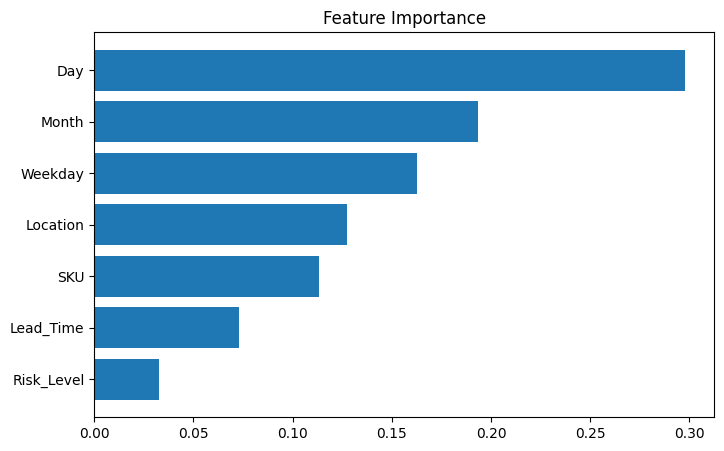

In [34]:
import matplotlib.pyplot as plt
importance=importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Feature Importance")

In [35]:
joblib.dump(
    rf_model,
    "../models/demand_forecasting_model.pkl"
)

['../models/demand_forecasting_model.pkl']

In [36]:
joblib.dump(
    sku_encoder,
    "../models/sku_encoder.pkl"
)

joblib.dump(
    location_encoder,
    "../models/location_encoder.pkl"
)

joblib.dump(
    risk_encoder,
    "../models/risk_encoder.pkl"
)

['../models/risk_encoder.pkl']

In [37]:
df["Qty_Sold"].describe()

count    1415.000000
mean       12.939929
std         7.229022
min         1.000000
25%         7.000000
50%        13.000000
75%        19.000000
max        25.000000
Name: Qty_Sold, dtype: float64

In [38]:
df.nunique()

Order_ID      1415
Date           358
SKU              7
Qty_Sold        25
Location         4
Staff_ID         4
Revenue        153
Lead_Time        5
Risk_Level       3
Year             1
Month           12
Day             31
Weekday          7
dtype: int64